# Quantum Convolutional Neural Network

This notebook demonstrates the package-client QCNN workflow implemented in `qml.qcnn`.

The model uses:

- a trainable four-qubit embedding
- shared convolution-style two-qubit blocks
- pooling-style entangling reductions before final readout

The notebook remains a thin client of the package API.

## Tutorial Goals

This tutorial walks through the compact quantum convolutional neural network workflow. You will:

- call the high-level `run_qcnn` API
- train a hierarchical four-qubit classifier
- inspect accuracy, loss, and decision-boundary artifacts
- compare the QCNN workflow shape with the VQC workflow

The notebook is a practical API tutorial, not a benchmark claim.

In [1]:
from pathlib import Path
import sys

repo_root = Path.cwd().resolve()
if not (repo_root / "src" / "qml").exists():
    repo_root = next(
        (parent for parent in repo_root.parents if (parent / "src" / "qml").exists()),
        repo_root,
    )
package_root = repo_root / "src"
if str(package_root) not in sys.path:
    sys.path.insert(0, str(package_root))

In [2]:
from qml.qcnn import run_qcnn

## Run a QCNN experiment

Train a small QCNN classifier on the two-moons dataset.

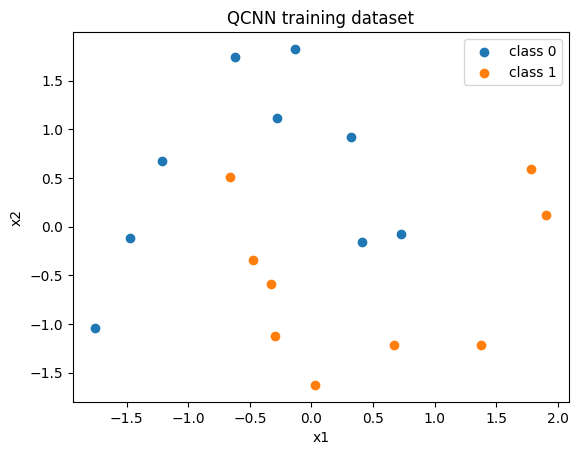

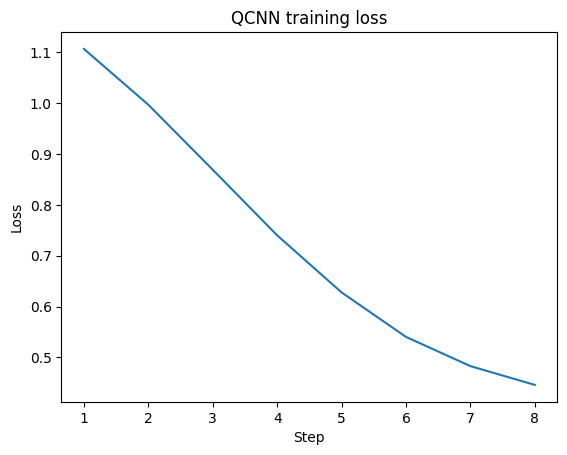

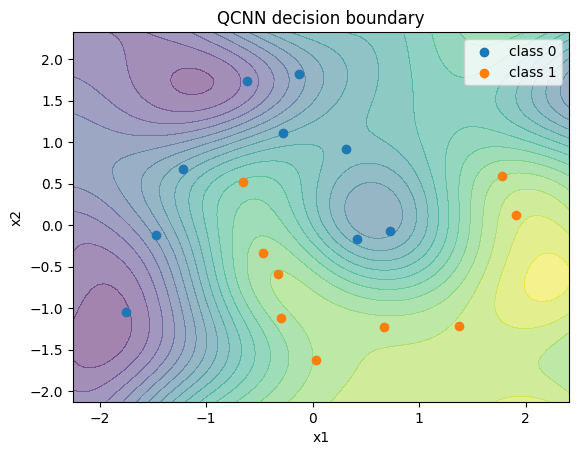

Train accuracy: 0.9444444444444444
Test accuracy: 1.0
Final loss: 0.42221349893739046


In [3]:
result = run_qcnn(
    dataset="moons",
    n_samples=24,
    noise=0.1,
    test_size=0.25,
    seed=123,
    steps=8,
    step_size=0.1,
    plot=True,
    save=True,
)

print("Train accuracy:", result["train_accuracy"])
print("Test accuracy:", result["test_accuracy"])
print("Final loss:", result["final_loss"])

## Inspect learned parameter blocks

In [4]:
print("Embedding params shape:", result["embedding_params"].shape)
print("First convolution block shape:", result["conv1_params"].shape)
print("Second convolution block shape:", result["conv2_params"].shape)
print("Dense readout params shape:", result["dense_params"].shape)

Embedding params shape: (4, 3)
First convolution block shape: (2, 6)
Second convolution block shape: (1, 6)
Dense readout params shape: (2,)


## Compare dataset choices

In [5]:
for dataset in ["moons", "circles", "blobs", "xor"]:
    res = run_qcnn(
        dataset=dataset,
        n_samples=20,
        noise=0.1,
        seed=123,
        steps=3,
        plot=False,
        save=False,
    )

    print()
    print(dataset)
    print("  train accuracy:", res["train_accuracy"])
    print("  test accuracy:", res["test_accuracy"])


moons
  train accuracy: 0.6666666666666666
  test accuracy: 0.8



circles
  train accuracy: 0.4666666666666667
  test accuracy: 0.4



blobs
  train accuracy: 1.0
  test accuracy: 1.0



xor
  train accuracy: 0.5333333333333333
  test accuracy: 0.4


## Finite-shot execution

In [6]:
result_shots = run_qcnn(
    dataset="moons",
    n_samples=20,
    noise=0.1,
    seed=123,
    steps=3,
    shots=20,
    plot=False,
    save=False,
)

print("Finite-shot train accuracy:", result_shots["train_accuracy"])
print("Finite-shot test accuracy:", result_shots["test_accuracy"])
print("Finite-shot final loss:", result_shots["final_loss"])

Finite-shot train accuracy: 0.4666666666666667
Finite-shot test accuracy: 1.0
Finite-shot final loss: 2.022702148492722
